<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

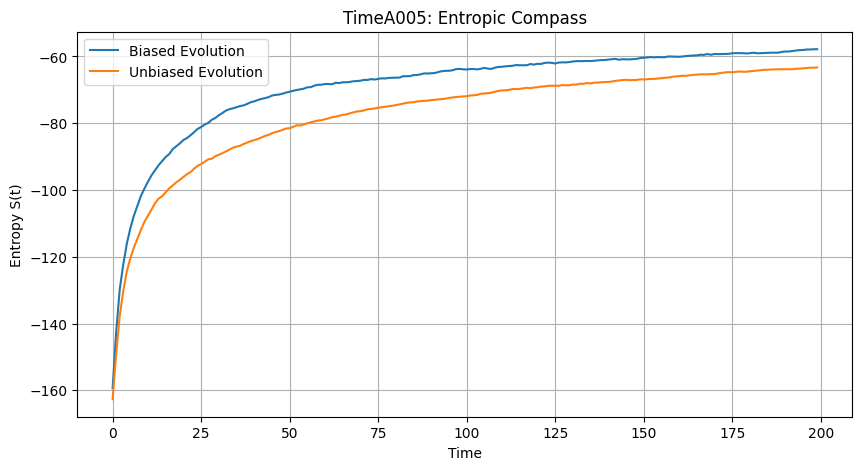

Biased Evolution Metrics:
Entropy Slope: 0.1920
Memory Retention: 0.9979
Irreversibility Index: 107.0859
Net Drift: -0.2172

Unbiased Evolution Metrics:
Entropy Slope: 0.2244
Memory Retention: 0.9984
Irreversibility Index: 100.8200
Net Drift: -0.2017


In [1]:
# 🧭 TimeA005: The Entropic Compass
# Exploring directional flow induced by entropy gradients in HES lattice
# Author: Chris & Copilot | Arc V: Entropic Ascent | ACT029
# Reproducibility Tag: TimeA005_v1

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100  # lattice size
T = 200  # timesteps
curvature_strength = 0.5
xi_locking = True
bias_strength = 0.05  # entropic bias magnitude
seed = 42
np.random.seed(seed)

# --- Initialization ---
def initialize_lattice(N, curvature_strength):
    base = np.random.rand(N, N)
    curvature = curvature_strength * (np.sin(np.linspace(0, np.pi, N))[:, None])
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Drift Calculation ---
def compute_drift(lattice, prev_lattice):
    return np.mean(lattice - prev_lattice)

# --- Evolution Functions ---
def evolve_biased(lattice, xi_locking, bias_strength):
    entropy_map = np.gradient(lattice)[0]  # simple proxy for entropy gradient
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_strength * entropy_map
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

def evolve_unbiased(lattice, xi_locking):
    lattice += 0.01 * np.random.randn(*lattice.shape)
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, curvature_strength, xi_locking, biased=False, bias_strength=0.0):
    lattice = initialize_lattice(N, curvature_strength)
    entropy_series = []
    drift_series = []
    for t in range(T):
        prev_lattice = lattice.copy()
        if biased:
            lattice = evolve_biased(lattice, xi_locking, bias_strength)
        else:
            lattice = evolve_unbiased(lattice, xi_locking)
        S = compute_entropy(lattice)
        drift = compute_drift(lattice, prev_lattice)
        entropy_series.append(S)
        drift_series.append(drift)
    return np.array(entropy_series), np.array(drift_series)

# --- Run Biased and Unbiased ---
biased_entropy, biased_drift = run_simulation(N, T, curvature_strength, xi_locking, biased=True, bias_strength=bias_strength)
unbiased_entropy, unbiased_drift = run_simulation(N, T, curvature_strength, xi_locking, biased=False)

# --- Metrics ---
def compute_metrics(entropy_series, drift_series):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    net_drift = np.sum(drift_series)
    return slope, memory, irreversibility_index, net_drift

biased_metrics = compute_metrics(biased_entropy, biased_drift)
unbiased_metrics = compute_metrics(unbiased_entropy, unbiased_drift)

# --- Plotting ---
plt.figure(figsize=(10,5))
plt.plot(biased_entropy, label='Biased Evolution')
plt.plot(unbiased_entropy, label='Unbiased Evolution')
plt.xlabel('Time')
plt.ylabel('Entropy S(t)')
plt.title('TimeA005: Entropic Compass')
plt.legend()
plt.grid(True)
plt.show()

# --- Output ---
print("Biased Evolution Metrics:")
print(f"Entropy Slope: {biased_metrics[0]:.4f}")
print(f"Memory Retention: {biased_metrics[1]:.4f}")
print(f"Irreversibility Index: {biased_metrics[2]:.4f}")
print(f"Net Drift: {biased_metrics[3]:.4f}")

print("\nUnbiased Evolution Metrics:")
print(f"Entropy Slope: {unbiased_metrics[0]:.4f}")
print(f"Memory Retention: {unbiased_metrics[1]:.4f}")
print(f"Irreversibility Index: {unbiased_metrics[2]:.4f}")
print(f"Net Drift: {unbiased_metrics[3]:.4f}")
